# Preprocessing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyinform.utils import coalesce_series, coalesce
from pyinform import transfer_entropy
import networkx as nx
from scipy import stats
import sys
print(sys.executable)

c:\Users\taoni\Documents\jc\venv\Scripts\python.exe


### Load data

In [49]:
data = np.genfromtxt("data.csv", delimiter=",")

# 1 Data normalization

In [50]:
print(data[0])

[  5.21560352   6.09997621  13.02125436 ...  34.0496583  -12.15346486
  17.27890364]


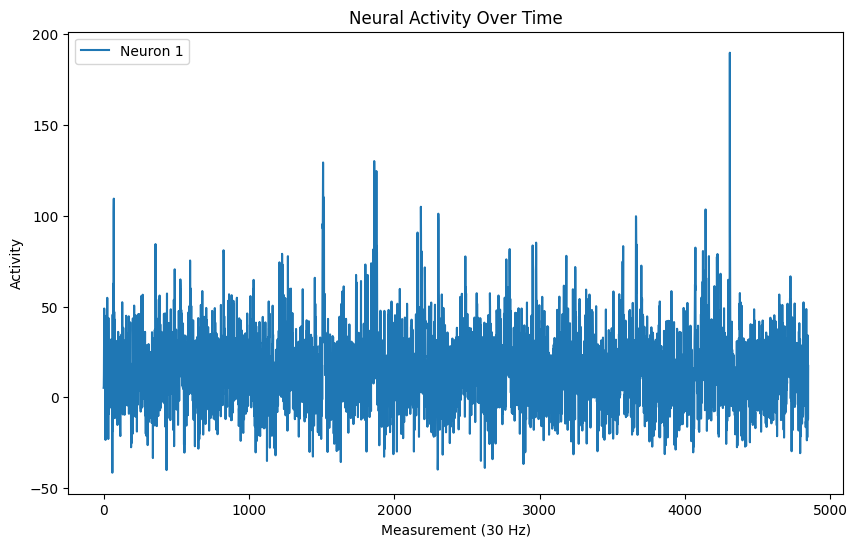

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(0, data.shape[1]), data[0,:], label="Neuron 1")
# plt.plot(np.arange(0, data.shape[1]), data[1,:], label="Neuron 2")
# plt.plot(np.arange(0, data.shape[1]), data[2,:], label="Neuron 3")
# plt.plot(np.arange(0, data.shape[1]), data[3,:], label="Neuron 4")
# plt.plot(np.arange(0, data.shape[1]), data[4,:], label="Neuron 5")

plt.xlabel("Measurement (30 Hz)")
plt.ylabel("Activity")
plt.title("Neural Activity Over Time")
plt.legend()
plt.show()

In [ ]:
# Relative change normalization (deltaF/F0)
window_size = 300
n_neurons, n_frames = data.shape

norm_data = np.zeros_like(data, dtype=float)

for i in range(n_neurons):
# for i in range(1):
    neuron = data[i]
    for t in range(n_frames):
        start = max(0, t - window_size)
        if t == 0:
            F0 = neuron[0]
        else:
            window = neuron[start:t]
            if window.size <= 1:
                F0 = neuron[0]
            else:
                median = np.percentile(window, 50)
                lower_half = window[window < median]
                F0 = np.mean(lower_half)
        if F0 == 0:
            F0 = 1e-6
        norm_data[i, t] = (neuron[t] - F0) / F0
    print(f"Neuron {i+1} normalized.")

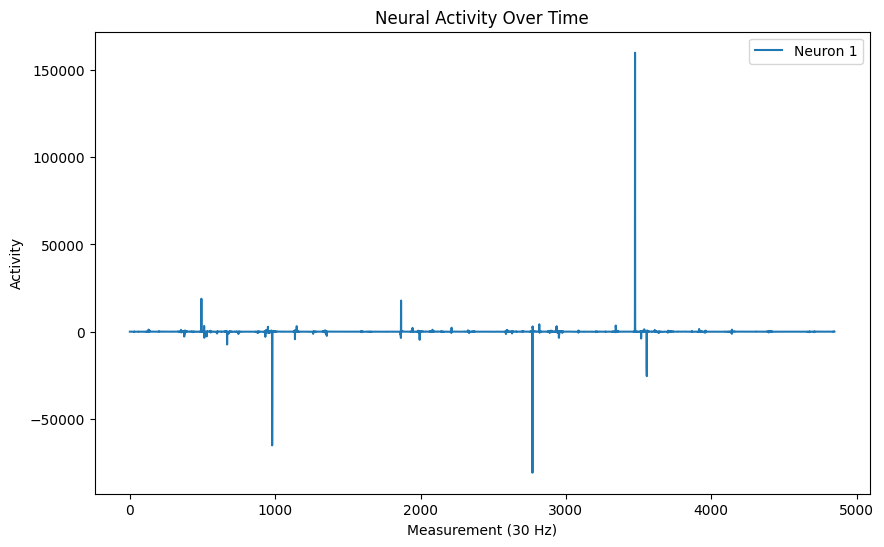

In [54]:
plt.figure(figsize=(10, 6))
plt.plot(norm_data[0,:], label="Neuron 1")
plt.xlabel("Measurement (30 Hz)")
plt.ylabel("Activity")
plt.title("Neural Activity Over Time")
plt.legend()
plt.show()

In [ ]:
# Old z-score normalization
# mean = np.mean(data, axis=1, keepdims=True)
# std = np.std(data, axis=1, keepdims=True)
# norm_data = (data - mean) / std + 1

# 2 Pearson correlation

### 2.1 Correlation matrix

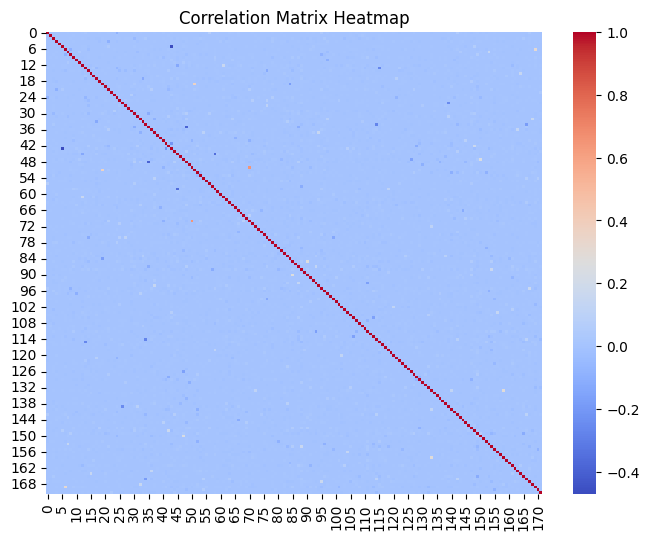

In [63]:
corr_matrix = np.corrcoef(norm_data)

# Plot correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Find maximum correlation, excluding 1s (correlation between neuron and itself)
# np.fill_diagonal(corr_matrix, -np.inf)
# print(corr_matrix.max())

### 2.2 Thresholded correlation matrix

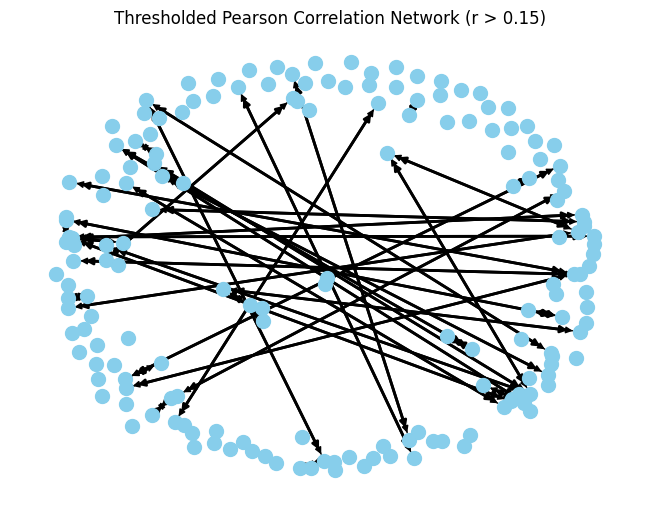

In [65]:
# Remove self-correlations
np.fill_diagonal(corr_matrix, 0)

# Threshold weak correlations
threshold = 0.1
corr_matrix[np.abs(corr_matrix) < threshold] = 0

# Create undirected weighted graph
G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)

pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos,
        node_color='skyblue',
        node_size=100)

nx.draw_networkx_edges(G, pos, width=2, edge_color='black')

# edge_labels = nx.get_edge_attributes(G, 'weight')
# nx.draw_networkx_edge_labels(G, pos) #, edge_labels=edge_labels)

plt.title("Thresholded Pearson Correlation Network (r > 0.15)")
plt.show()

In [68]:
nx.write_graphml(G, "neurons.graphml") 
# To read back: G = nx.read_graphml("my_graph.graphml")

### 2.3 p-value analysis

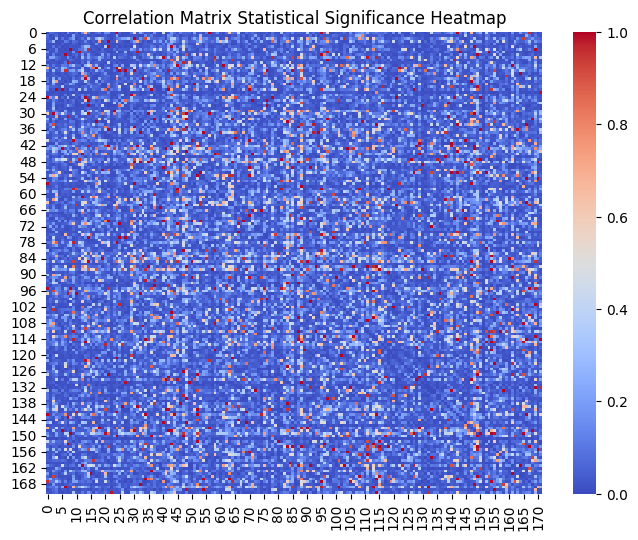

In [67]:
# Output a matrix with calculated p-values for the correlation matrix
n_neurons = norm_data.shape[0]
p_matrix = np.ones((n_neurons, n_neurons))
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        if i != j:
            p_matrix[i, j] = 1 - stats.pearsonr(norm_data[i], norm_data[j])[1]

    p_matrix[i, i] = 0  # self-comparison
plt.figure(figsize=(8, 6))
sns.heatmap(p_matrix, cmap='coolwarm')
plt.title('Correlation Matrix Statistical Significance Heatmap')
plt.show()


# 3 Transfer entropy

### 3.1 Transfer entropy matrix

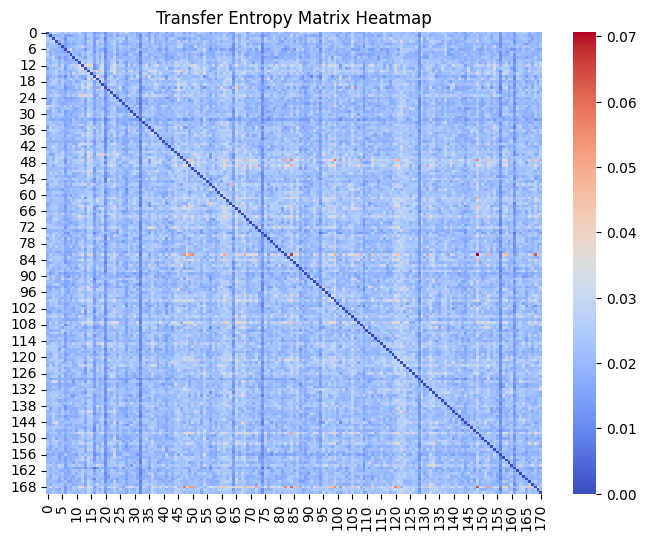

In [9]:
# Coalesce the series to positive integers for transfer entropy calculation in PyInform
def coalesce_row(row):
    # Returns (coalesced_row, base)
    return coalesce_series(row)[0]
coalesced_data = np.apply_along_axis(coalesce_row, 1, norm_data)

te_matrix = np.zeros((n_neurons, n_neurons))

k = 1  # history length

for i in range(n_neurons):
    for j in range(n_neurons):
        if i != j:
            te_matrix[i, j] = transfer_entropy(coalesced_data[i], coalesced_data[j], k=k)

# Transfer entropy matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(te_matrix, cmap='coolwarm')
plt.title('Transfer Entropy Matrix Heatmap')
plt.show()

In [10]:
# 3. Statistical filtering
# For each pair:
    # Shuffle source neuron
    # Recompute TE
    # Build null distribution
    # Compute p-value

# data_array = coalesced_data[:, :, np.newaxis]  # using coalesced data for TE calculation

# data = Data(
#     data_array,
#     dim_order='psr'  # processes, samples (time)
# )
# #shuffling is done internally by the BivariateTE class when performing permutation testing
# settings = {
#     'cmi_estimator': 'jidt_discrete',
#     'min_lag_sources': 1,
#     'max_lag_sources': 5,
#     'n_perm_max_stat': 100  # number of permutations for null distribution
# }
# # results will contain the TE values and p-values for each pair of neurons
# bte = BivariateTE()
# %pip install setuptools==68.0.0
# results = bte.analyse_network(settings=settings, data=data)
# n = data.n_processes
# te_matrix = np.zeros((n, n))
# p_matrix = np.ones((n, n))
# # Fill the TE and p-value matrices from the results
# for target in results.targets_analysed:
#     sources = results.get_target_sources(target)
#     for source in sources:
#         te_val = results.get_single_edge(source, target, 'te')
#         p_val = results.get_single_edge(source, target, 'pval')
#         te_matrix[source, target] = te_val
#         p_matrix[source, target] = p_val
# #heatmap
# plt.figure(figsize=(8, 6))
# sig_te = np.where(p_matrix < 0.05, te_matrix, 0)
# sns.heatmap(sig_te, cmap='coolwarm')
# plt.title('Transfer Entropy (p < 0.05) heatmap')
# plt.xlabel('Target neuron')
# plt.ylabel('Source neuron')
# plt.show()

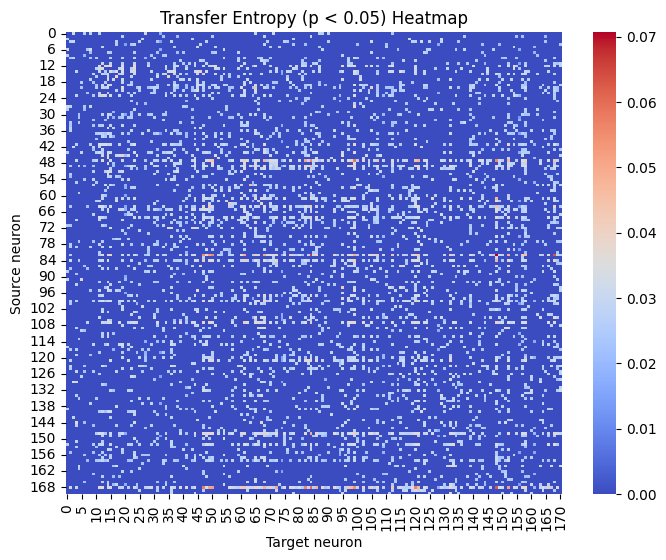

In [11]:
te_matrix = np.zeros((n_neurons, n_neurons))

# Compute TE for all pairs (i, j)
for i in range(n_neurons):
    for j in range(n_neurons):
        if i != j:
            te_matrix[i, j] = transfer_entropy(
                coalesced_data[i],
                coalesced_data[j],
                k=1
            )
            
# Now compute p-values using surrogate data
n_surrogates = 100
p_matrix = np.ones((n_neurons, n_neurons))

# Compute p-values for all pairs (i, j)
for i in range(n_neurons):
    for j in range(n_neurons):
        if i == j:
            continue
        source = coalesced_data[i]
        target = coalesced_data[j]
        true_te = te_matrix[i, j]
        null_dist = np.zeros(n_surrogates)
        for s in range(n_surrogates):
            shift = np.random.randint(len(source))
            surrogate = np.roll(source, shift)
            null_dist[s] = transfer_entropy(surrogate, target, k=1)
        p_matrix[i, j] = np.mean(null_dist >= true_te)
sig_te = np.where(p_matrix < 0.05, te_matrix, 0)

plt.figure(figsize=(8, 6))
sns.heatmap(sig_te, cmap='coolwarm')
plt.title('Transfer Entropy (p < 0.05) Heatmap')
plt.xlabel('Target neuron')
plt.ylabel('Source neuron')
plt.show()

Thresholding/sparsification options:

- Fixed TE threshold

- Statistical threshold (preferred) 

- Top X% strongest edges 

- False Discovery Rate (FDR)